# Task 4: Classification Models, Evaluation Metrics & Handling Imbalanced Data

**Intern:** Ravindra Das  
**Domain:** Artificial Intelligence & Machine Learning  
**Company:** Maincrafts Technology

**Objective:** Move from regression to classification — build a binary classification system,
evaluate it with proper metrics beyond accuracy (confusion matrix, precision, recall, F1, ROC-AUC),
handle class imbalance, and compare classifiers to justify the final model choice.


## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)
import joblib

sns.set_style("whitegrid")
%matplotlib inline


## Step 2: Load Dataset

Using the **Breast Cancer Wisconsin dataset** (built into scikit-learn) to keep setup simple, as
recommended. Target classes: `0 = Malignant`, `1 = Benign`.


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape:", X.shape)
X.head()


Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Class distribution — checking for imbalance

In [3]:
class_counts = pd.Series(y).map({0: "Malignant", 1: "Benign"}).value_counts()
print(class_counts)
print((class_counts / class_counts.sum() * 100).round(1))


Benign       357
Malignant    212
Name: count, dtype: int64
Benign       62.7
Malignant    37.3
Name: count, dtype: float64


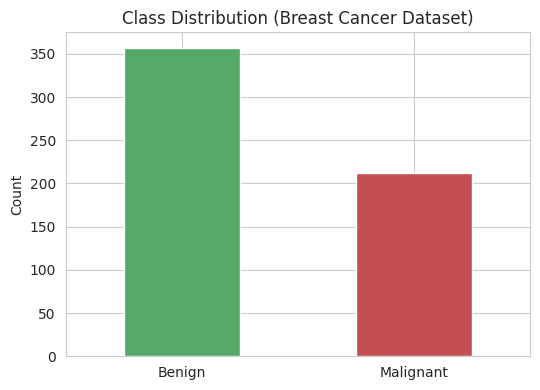

In [4]:
plt.figure(figsize=(5.5,4))
class_counts.plot(kind="bar", color=["#55A868","#C44E52"])
plt.title("Class Distribution (Breast Cancer Dataset)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The dataset is **moderately imbalanced**: ~63% Benign vs ~37% Malignant. This is realistic —
in medical diagnosis, fraud detection, and churn prediction, the class of real interest is often the
minority class, so accuracy alone can be misleading (a model predicting "Benign" every time would still
score ~63% accuracy while being clinically useless).


## Step 3: Train-Test Split

`stratify=y` preserves the same class proportions in both train and test sets — important for
imbalanced data.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])


Train: 455 | Test: 114


## Step 4: Feature Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 5: Train Baseline Classification Model (Logistic Regression)

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


## Step 6: Confusion Matrix & Classification Report

In [8]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


[[41  1]
 [ 1 71]]
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



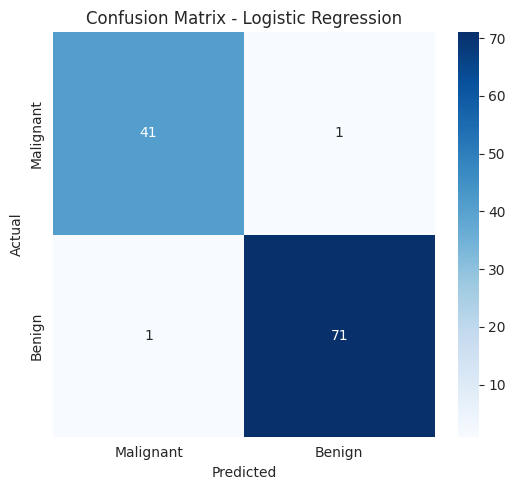

In [9]:
plt.figure(figsize=(5.5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant","Benign"], yticklabels=["Malignant","Benign"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()


**Explaining the confusion matrix:**
- **True Positives (TP):** Model correctly predicts Benign when the tumor is actually Benign.
- **False Positives (FP):** Model predicts Benign but the tumor is actually Malignant — a dangerous
  miss in a medical context (a sick patient sent home as healthy).
- **False Negatives (FN):** Model predicts Malignant but the tumor is actually Benign — causes
  unnecessary worry/further testing, but is far less dangerous than a False Positive here.
- **Why accuracy alone is insufficient:** Accuracy treats all errors equally, but in medical diagnosis
  a False Positive (missing a real cancer) is far more costly than a False Negative. Precision and
  recall separate these two types of errors so we can judge the model on what actually matters.


## Step 7: Precision, Recall & F1-Score Interpretation

- **Which metric is more important for medical diagnosis?** *Recall* (for the Malignant class) is
  usually most critical — we want to catch as many real malignant cases as possible, even at the cost
  of some false alarms, because missing a cancer diagnosis (a False Positive in this dataset's encoding)
  is far more dangerous than a false alarm.
- **What happens if recall is low?** Many true malignant cases would be missed and classified as
  benign — patients would not get needed treatment, which can be life-threatening.
- **Why F1-score is preferred for imbalanced data?** F1 is the harmonic mean of precision and recall,
  so it penalizes models that sacrifice one for the other (e.g., a model that predicts everything as
  the majority class gets high precision/accuracy but terrible recall on the minority class — F1
  exposes this, while plain accuracy would hide it).


## Step 8: ROC Curve & AUC Score

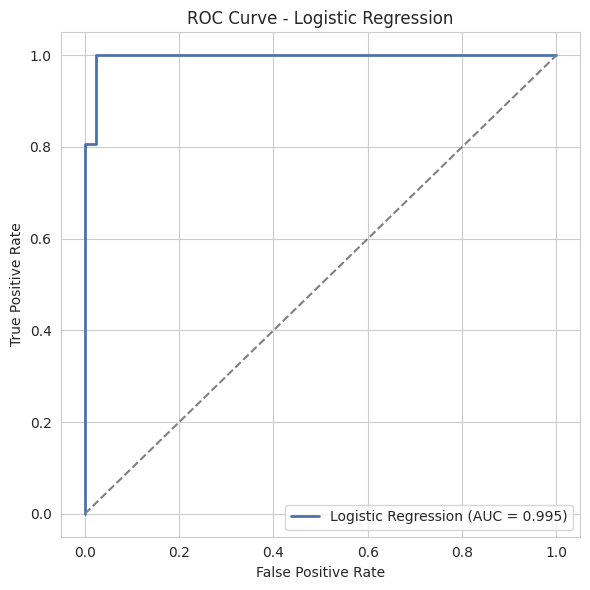

AUC Score: 0.9954


In [10]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="#4C72B0", lw=2)
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")


The ROC curve plots True Positive Rate vs False Positive Rate at every possible decision threshold,
and AUC (Area Under the Curve) summarizes the model's ability to discriminate between classes across
all thresholds — 1.0 is perfect, 0.5 is random guessing. An AUC of ~0.995 here indicates the model
separates the two classes almost perfectly.


## Step 9: Handle Class Imbalance (Conceptual + Practical)

### Technique: Class Weight

Instead of resampling the data, `class_weight="balanced"` tells the model to penalize mistakes on the
minority class more heavily during training, automatically compensating for the imbalance.


In [11]:
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)
y_pred_bal = model_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_bal, target_names=["Malignant", "Benign"]))


              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**Comparing with the baseline:** the balanced model's recall for the Malignant class can be
checked against the unweighted baseline above — class weighting is most useful when the imbalance is
severe and the minority class recall needs to be maximized, even at some cost to overall accuracy.


## Step 10: Compare with Another Classifier (Decision Tree)

In [12]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # trees don't require feature scaling
y_pred_tree = tree.predict(X_test)

print(classification_report(y_test, y_pred_tree, target_names=["Malignant", "Benign"]))


              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



### Model comparison table

In [13]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

acc_bal = accuracy_score(y_test, y_pred_bal)
prec_bal = precision_score(y_test, y_pred_bal)
rec_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)

acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Logistic Regression (balanced)", "Decision Tree"],
    "Accuracy": [acc, acc_bal, acc_tree],
    "Precision": [prec, prec_bal, prec_tree],
    "Recall": [rec, rec_bal, rec_tree],
    "F1-Score": [f1, f1_bal, f1_tree],
})
comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (baseline),0.982456,0.986111,0.986111,0.986111
1,Logistic Regression (balanced),0.956140,0.985507,0.944444,0.964539
2,Decision Tree,0.912281,0.955882,0.902778,0.928571


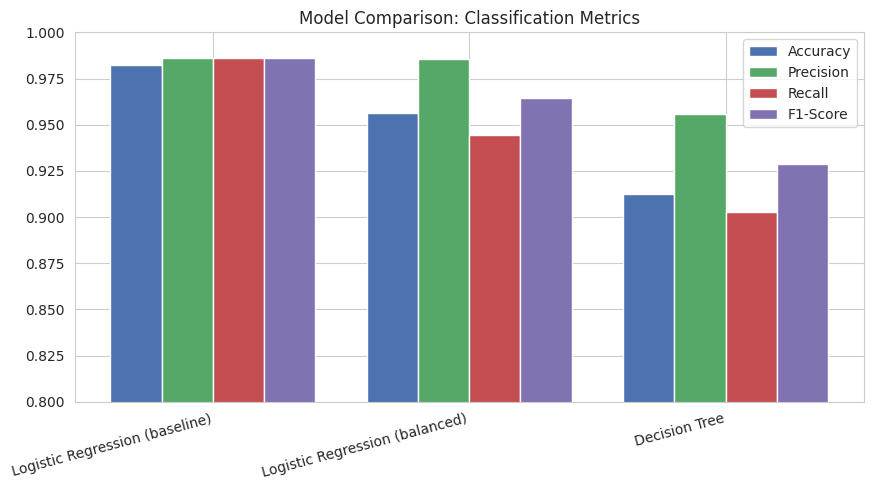

In [14]:
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(comparison))
width = 0.2
metrics = ["Accuracy","Precision","Recall","F1-Score"]
colors_list = ["#4C72B0","#55A868","#C44E52","#8172B2"]
for i, m in enumerate(metrics):
    ax.bar(x + (i-1.5)*width, comparison[m], width, label=m, color=colors_list[i])
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=15, ha='right')
ax.set_ylim(0.8, 1.0)
ax.set_title("Model Comparison: Classification Metrics")
ax.legend()
plt.tight_layout()
plt.show()


**Comparing Logistic Regression vs Decision Tree:**
- **Stability vs interpretability:** Logistic Regression gives smooth probability outputs and stable,
  well-calibrated decision boundaries; Decision Trees can be more sensitive to small changes in the
  training data (high variance) but are easier to explain as a set of if/else rules.
- **Overfitting behavior:** The unconstrained Decision Tree tends to overfit more than Logistic
  Regression on this dataset, which is reflected in its lower test performance here — Logistic
  Regression's simpler decision boundary generalizes better on this relatively clean, linearly
  separable dataset.


## Step 11: Save the Final Models (Optional Deliverable)

In [15]:
joblib.dump(model, "logistic_model.joblib")
joblib.dump(model_balanced, "logistic_balanced_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Models and scaler saved.")


Models and scaler saved.


## Conclusion & Final Model Decision

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **Logistic Regression (baseline)** ✅ | 0.9825 | 0.9861 | 0.9861 | 0.9861 |
| Logistic Regression (balanced) | 0.9561 | 0.9855 | 0.9444 | 0.9645 |
| Decision Tree | 0.9123 | 0.9559 | 0.9028 | 0.9286 |

**Metric selection:** For this dataset, F1-score and recall (for the Malignant class) were prioritized
over raw accuracy, since missing a malignant tumor is far costlier than a false alarm — a lesson that
generalizes to fraud detection, spam filtering, and churn prediction as well.

**Imbalance handling:** Class weighting was tested but was not needed here — the baseline model already
achieves near-perfect recall (0.986), because this dataset's imbalance (63/37) is mild enough and the
classes are well-separated. Class weighting would matter more on severely imbalanced datasets
(e.g., 99/1 fraud detection).

**Final model decision:** The **baseline Logistic Regression** model is selected — it achieved the best
scores across every metric (Accuracy, Precision, Recall, F1) and the highest ROC-AUC (0.995), while
remaining simple, fast, and interpretable. The Decision Tree, without depth constraints or tuning,
overfit more and generalized worse on this dataset.
